## Cài đặt thư viện

In [ ]:
!pip install -q easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 22.3 MB/s eta 0:00:00


## Data thực tế

In [ ]:
# Code hiển thị ảnh
import matplotlib.pyplot as plt
from PIL import Image

def show_image(path_or_img, figsize=(5, 7), title=None):
    img = Image.open(path_or_img) if isinstance(path_or_img, str) else path_or_img
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis('off')
    if title:
        plt.title(title)
    plt.show()

Downloading...
From: https://drive.google.com/uc?id=1MjLhbtFIjV7bOyrYfYNUsviJ1hO7wnRp
To: /content/new_image.png
100%|██████████| 566k/566k [00:00<00:00, 88.9MB/s]


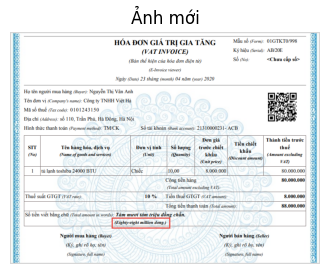

In [ ]:
import gdown

file_id = "1MjLhbtFIjV7bOyrYfYNUsviJ1hO7wnRp"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "new_image.png", quiet=False)

show_image("new_image.png", figsize=(4, 6), title="Ảnh mới")

## EasyOCR

In [ ]:
import easyocr

# Khởi tạo reader với tiếng Việt + tiếng Anh
# gpu=False nếu chạy CPU, đổi True nếu có GPU
reader = easyocr.Reader(['vi', 'en'], gpu=False)

# Chạy OCR trên ảnh — trả về list (box, text, confidence) cho từng vùng
results = reader.readtext('new_image.png')

# In kết quả
for box, text, conf in results:
    print(f"{conf:.3f} | {text}")

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


0.303 | 9
0.845 | HÓA ĐƠN GIÁ TRỊ GIA TĂNG
0.411 | Mẳu sổ (Form):
0.798 | OIGTKTO 998
0.659 | (VAT INVOICE)
0.499 | Ký hiệu (Serial): AB ZOE
0.430 | (Bản thê hiện cúa hóa đơn điện tử)
0.532 | Só (No):
0.229 | <Chưa cẩp sô>
0.022 | {
0.683 | Ngay
0.253 | 23 tháing omontb) 04 năm (ear) 2020
0.404 | 1
0.945 | Họ tên
0.640 | Mua
0.658 | hàng (Buyer): Nguyén Thị Vàn Anh
0.611 | Ten don vị
0.429 | Companvs name) :
0.968 | Công
0.811 | TNHH Việt Hà
0.830 | Mã số thuế (Tax code): 0101243150
0.362 | 8
0.229 | Địa chỉ (Address) : sổ 110, Trẩn Phú, Hà Đông, Hà Nội
0.941 | 8
0.511 | Hinh thức thanh toán (Payment method) : TMCK
0.614 | Sò tài khoan (Bank account): 21310000231
0.999 | ACB
0.966 | Đơn giá
0.635 | Thành tiên trước
0.863 | Tiên chiêt
1.000 | Tên
0.898 | hóa, dịch
0.887 | Đơn vị tinh
0.449 | Sổ Iượng
0.754 | trước chiết
0.530 | khau
0.966 | thuế
0.078 | 1
0.656 | (No)
0.073 | Oaie
0.914 | of goods and services)
0.986 | (Unit)
0.941 | Quantity)
0.493 | khấu
0.016 | Korunt
0.995 | excludi

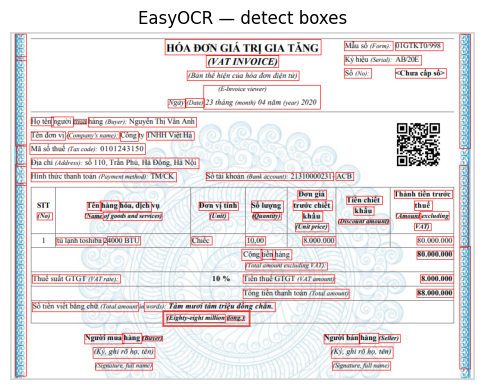

In [ ]:
# Vẽ box lên ảnh để xem trực quan
from PIL import Image, ImageDraw

img = Image.open('new_image.png').convert("RGB")
draw = ImageDraw.Draw(img)

for box, text, conf in results:
    # box là 4 điểm góc, lấy toạ độ min/max để vẽ hình chữ nhật
    xs = [p[0] for p in box]
    ys = [p[1] for p in box]
    draw.rectangle([min(xs), min(ys), max(xs), max(ys)], outline="red", width=1)

show_image(img, figsize=(6, 9), title="EasyOCR — detect boxes")

In [ ]:
# Bảng kết quả
import pandas as pd

df_easyocr = pd.DataFrame([
    {"text": text, "confidence": round(conf, 3)}
    for box, text, conf in results
])
df_easyocr

,text,confidence
0,9,0.303
1,HÓA ĐƠN GIÁ TRỊ GIA TĂNG,0.845
2,Mẳu sổ (Form):,0.411
3,OIGTKTO 998,0.798
4,(VAT INVOICE),0.659
...,...,...
79,hang,0.809
80,Cong,0.597
81,hang,0.996
82,hang,0.944
